In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense,GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import MobileNetV2
from sklearn.utils import shuffle
import torch

2025-04-23 18:10:53.269832: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745431853.479767      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745431853.536686      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
DATA_DIR = "/kaggle/input/fer2013"
# ---------------- Datasets ----------------
# Label mapping
label_map = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'sad': 4,
    'surprise': 5,
    'neutral': 6
}

def load_images_from_folder(folder_path, img_size=(48, 48)):
    X, y = [], []
    for label in os.listdir(folder_path):  # e.g., "angry", "happy", etc.
        label_path = os.path.join(folder_path, label)
        if not os.path.isdir(label_path):
            continue
        for img_file in os.listdir(label_path):
            img_path = os.path.join(label_path, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, img_size)
                X.append(img)
                y.append(label_map[label.lower()])  # map string to integer label
    return np.array(X), np.array(y)
# Load train and test
train_path = os.path.join(DATA_DIR, 'train')
test_path = os.path.join(DATA_DIR, 'test')
X_train, y_train = load_images_from_folder(train_path)
X_test, y_test = load_images_from_folder(test_path)
# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0
# Reshape for CNN input: (samples, height, width, channels)
X_train = X_train.reshape(-1, 48, 48, 1)
X_test = X_test.reshape(-1, 48, 48, 1)
print(len(y_test),len(y_train))

7178 28709


In [3]:
# One-hot encode test set only (not train yet)
y_test = to_categorical(y_test, num_classes=7)
# Desired validation class counts (same as test)
desired_val_counts = {
    0: 958,   # Angry
    1: 111,   # Disgust
    2: 1024,  # Fear
    3: 1774,  # Happy
    4: 1247,  # Sad
    5: 831,   # Surprise
    6: 1233   # Neutral
}
# Convert X_train to numpy array (in case it's a list)
X_train = np.array(X_train)
y_train = np.array(y_train)

X_val, y_val = [], []
used_indices = set()

# Extract validation samples matching test distribution
for label, count in desired_val_counts.items():
    indices = np.where(y_train == label)[0]
    selected = np.random.choice(indices, size=count, replace=False)
    X_val.append(X_train[selected])
    y_val.append(y_train[selected])
    used_indices.update(selected.tolist())
# Combine validation
X_val = np.concatenate(X_val)
y_val = np.concatenate(y_val)
# Build the final training set with the rest
mask = np.ones(len(X_train), dtype=bool)
mask[list(used_indices)] = False
X_train_final = X_train[mask]
y_train_final = y_train[mask]
# Shuffle final train set
X_train_final, y_train_final = shuffle(X_train_final, y_train_final, random_state=42)
# One-hot encode labels
y_train_final_oh = to_categorical(y_train_final, num_classes=7)
y_val_oh = to_categorical(y_val, num_classes=7)
# Reverse label map for plotting
label_map_inv = {v: k.capitalize() for k, v in label_map.items()}
# For visualization and counts
y_train_labels = y_train_final
y_val_labels = y_val
y_test_labels = np.argmax(y_test, axis=1)

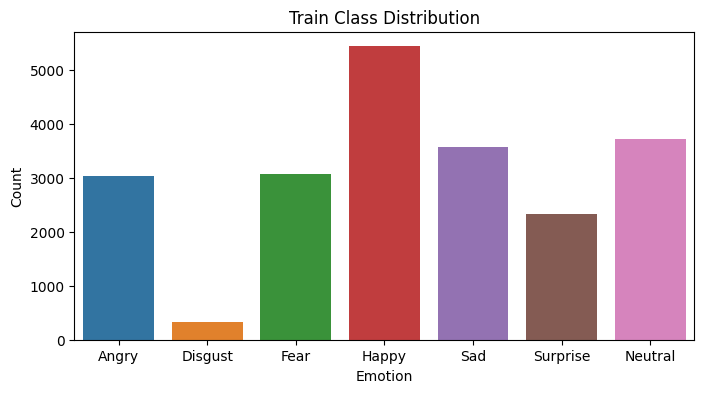

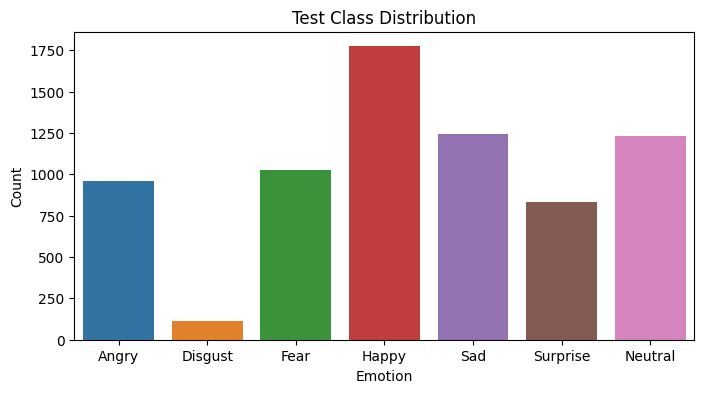

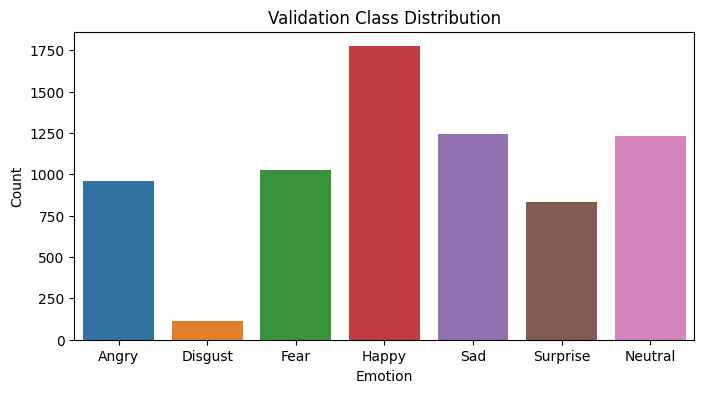

In [4]:
# Plot class distributions
for title, labels in zip(["Train", "Test", "Validation"],
                         [y_train_labels, y_test_labels, y_val_labels]):
    plt.figure(figsize=(8, 4))
    sns.countplot(x=labels)
    plt.title(f"{title} Class Distribution")
    plt.xticks(ticks=range(7), labels=[label_map_inv[i] for i in range(7)])
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.show()


In [5]:
# Print class counts
def print_class_counts(name, labels):
    unique_labels, counts = np.unique(labels, return_counts=True)
    print(f"\n{name} Class Counts:")
    for label, count in zip(unique_labels, counts):
        print(f"{label_map_inv[label]}: {count}")

print_class_counts("Train", y_train_labels)
print_class_counts("Test", y_test_labels)
print_class_counts("Validation", y_val_labels)


Train Class Counts:
Angry: 3037
Disgust: 325
Fear: 3073
Happy: 5441
Sad: 3583
Surprise: 2340
Neutral: 3732

Test Class Counts:
Angry: 958
Disgust: 111
Fear: 1024
Happy: 1774
Sad: 1247
Surprise: 831
Neutral: 1233

Validation Class Counts:
Angry: 958
Disgust: 111
Fear: 1024
Happy: 1774
Sad: 1247
Surprise: 831
Neutral: 1233


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Compute class weights from final training labels (not one-hot)
class_weights = compute_class_weight(class_weight='balanced',classes=np.unique(y_train_labels),y=y_train_labels)
# Convert to PyTorch tensor and move to device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights_tensor)


Class weights: tensor([1.0128, 9.4642, 1.0009, 0.5653, 0.8585, 1.3145, 0.8242],
       device='cuda:0')


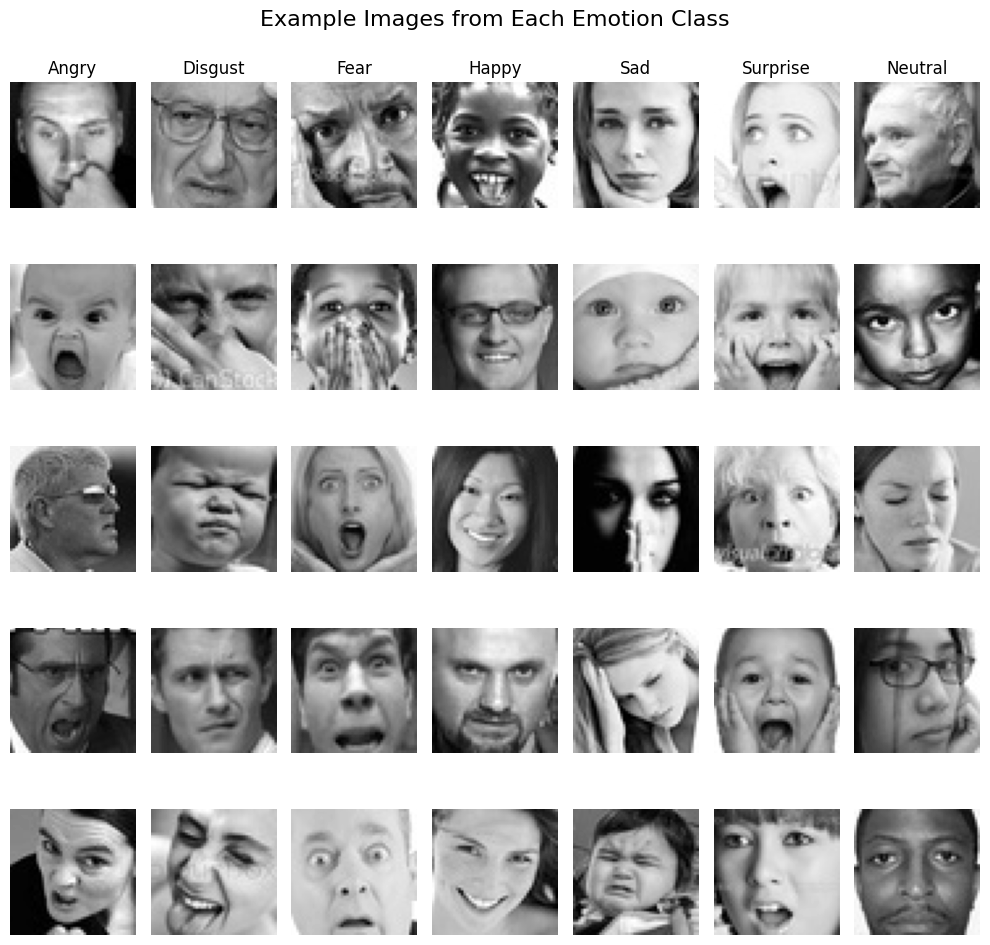

In [7]:

def show_examples(X, y, label_map_inv, samples_per_class=5):
    plt.figure(figsize=(samples_per_class * 2, 10))
    for class_id in range(7):
        idxs = np.where(np.argmax(y, axis=1) == class_id)[0][:samples_per_class]
        for i, idx in enumerate(idxs):
            plt_idx = i * 7 + class_id + 1
            plt.subplot(samples_per_class, 7, plt_idx)
            plt.imshow(X[idx].reshape(48, 48), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.title(label_map_inv[class_id])
    plt.suptitle("Example Images from Each Emotion Class", fontsize=16)
    plt.tight_layout()
    plt.show()
show_examples(X_train_final, y_train_final_oh, label_map_inv)

In [8]:
# Assuming y_train is already one-hot encoded
y_train_labels = np.argmax(y_train_final_oh, axis=1)  # Get the original integer labels
# Calculate class weights based on the original labels
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: 1.012794581118585, 1: 9.464175824175824, 2: 1.0009297568685789, 3: 0.5653109985034264, 4: 0.858458594154938, 5: 1.3144688644688645, 6: 0.824184657785944}


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.utils import shuffle
import numpy as np
from PIL import Image
import torch.nn.functional as F

# --- Dataset Class ---
class FERDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        if image.ndim == 3:
            image = image.squeeze()

        if image.max() <= 1.0:
            image = (image * 255).astype(np.uint8)

        image = Image.fromarray(image).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# --- Transforms ---
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Dataset and DataLoaders ---
batch_size = 128
# Convert one-hot labels to class indices if needed
if y_test.ndim > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)
if y_val.ndim > 1 and y_val.shape[1] > 1:
    y_val = np.argmax(y_val, axis=1)
if y_train_final.ndim > 1 and y_train_final.shape[1] > 1:
    y_train_final = np.argmax(y_train_final, axis=1)

train_dataset = FERDataset(X_train_final, y_train_final, train_transform)
val_dataset = FERDataset(X_val, y_val, eval_transform)
test_dataset = FERDataset(X_test, y_test, eval_transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- Model with Dropout ---
class ResNetWithDropout(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.base_model = models.resnet50(pretrained=True)
        in_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 7)
        )

    def forward(self, x):
        return self.base_model(x)

model = ResNetWithDropout().to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
device = next(model.parameters()).device

# --- Loss Function and Optimizer ---
class_weights = torch.tensor(class_weights, dtype=torch.float32)
class_weights = class_weights / class_weights.sum()  # Normalize
class_weights = class_weights.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optional: Use Label Smoothing instead
class LabelSmoothingLoss(nn.Module):
    def __init__(self, classes, smoothing=0.1):
        super().__init__()
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.cls = classes
        self.log_softmax = nn.LogSoftmax(dim=1)
    def forward(self, x, target):
        log_probs = self.log_softmax(x)
        true_dist = torch.zeros_like(log_probs)
        true_dist.fill_(self.smoothing / (self.cls - 1))
        true_dist.scatter_(1, target.data.unsqueeze(1), self.confidence)
        return torch.mean(torch.sum(-true_dist * log_probs, dim=1))
criterion = LabelSmoothingLoss(classes=7, smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

# --- Training Loop with Early Stopping ---
num_epochs = 40
best_val_acc = 0
patience = 5
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    scheduler.step(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    # Early stopping check
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "best_model_resnet.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(

Epoch [1/40] Train Loss: 1.5127, Train Acc: 0.4796, Val Acc: 0.5088
Epoch [2/40] Train Loss: 1.3687, Train Acc: 0.5585, Val Acc: 0.5107
Epoch [3/40] Train Loss: 1.3178, Train Acc: 0.5860, Val Acc: 0.4978
Epoch [4/40] Train Loss: 1.2865, Train Acc: 0.6008, Val Acc: 0.6013
Epoch [5/40] Train Loss: 1.2579, Train Acc: 0.6165, Val Acc: 0.5906
Epoch [6/40] Train Loss: 1.2316, Train Acc: 0.6303, Val Acc: 0.5132
Epoch [7/40] Train Loss: 1.2185, Train Acc: 0.6387, Val Acc: 0.6220
Epoch [8/40] Train Loss: 1.1966, Train Acc: 0.6477, Val Acc: 0.6284
Epoch [9/40] Train Loss: 1.1837, Train Acc: 0.6537, Val Acc: 0.6375
Epoch [10/40] Train Loss: 1.1661, Train Acc: 0.6677, Val Acc: 0.6258
Epoch [11/40] Train Loss: 1.1549, Train Acc: 0.6740, Val Acc: 0.6237
Epoch [12/40] Train Loss: 1.1416, Train Acc: 0.6793, Val Acc: 0.6152
Epoch [13/40] Train Loss: 1.0779, Train Acc: 0.7139, Val Acc: 0.6704
Epoch [14/40] Train Loss: 1.0544, Train Acc: 0.7261, Val Acc: 0.6629
Epoch [15/40] Train Loss: 1.0361, Train Acc

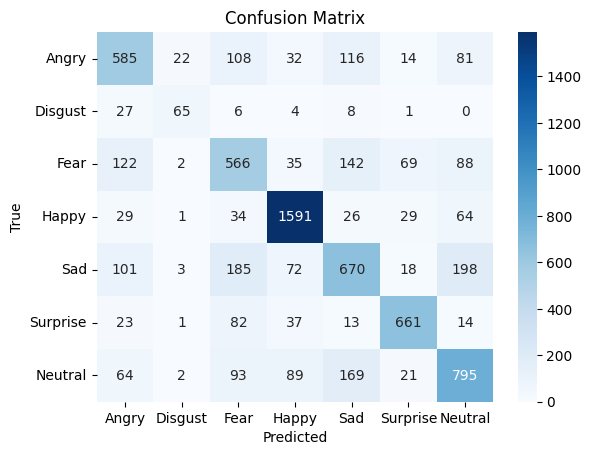

              precision    recall  f1-score   support

       Angry       0.62      0.61      0.61       958
     Disgust       0.68      0.59      0.63       111
        Fear       0.53      0.55      0.54      1024
       Happy       0.86      0.90      0.88      1774
         Sad       0.59      0.54      0.56      1247
    Surprise       0.81      0.80      0.80       831
     Neutral       0.64      0.64      0.64      1233

    accuracy                           0.69      7178
   macro avg       0.67      0.66      0.67      7178
weighted avg       0.69      0.69      0.69      7178



In [10]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Make sure everything is int
all_preds = np.array(all_preds).astype(int)
all_labels = np.array(all_labels).astype(int)

# Class names
emotion_classes = ["Angry", "Disgust", "Fear", "Happy", "Sad", "Surprise", "Neutral"]

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_classes, yticklabels=emotion_classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(all_labels, all_preds, target_names=emotion_classes))


Total misclassified: 2245


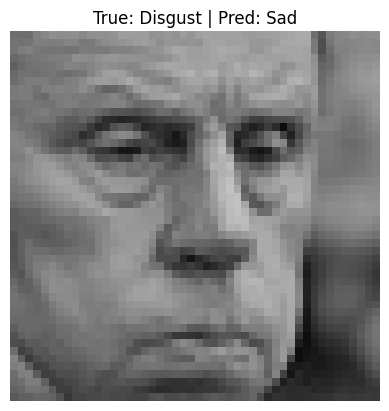

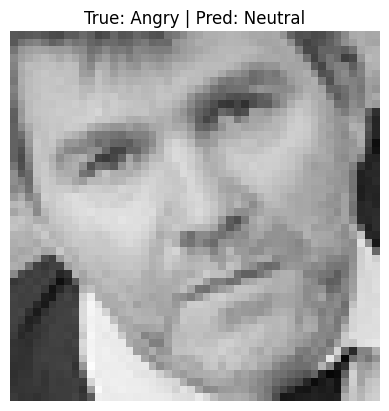

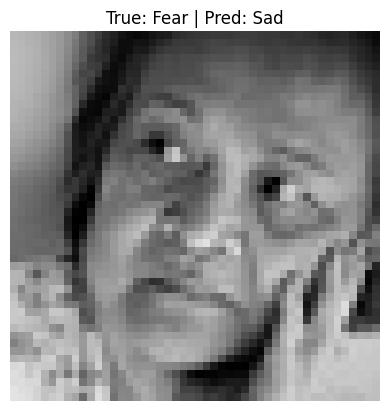

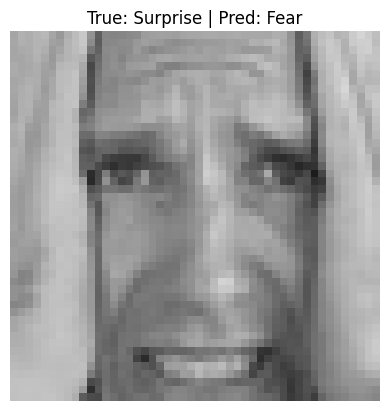

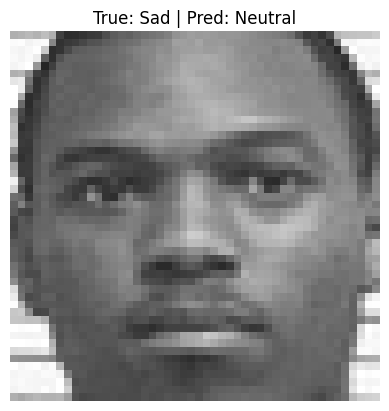

In [11]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Pick misclassified indices
misclassified_idxs = [i for i, (p, l) in enumerate(zip(all_preds, all_labels)) if p != l]
print(f"Total misclassified: {len(misclassified_idxs)}")

# Safely sample
sample_size = min(5, len(misclassified_idxs))
for i in random.sample(misclassified_idxs, sample_size):
    img = X_test[i]
    
    # Ensure shape is 2D or 3D grayscale (48x48 or 48x48x1)
    if img.ndim == 3:
        img = img.squeeze()
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    
    # Convert to RGB for display
    img = Image.fromarray(img).convert("RGB")

    plt.imshow(img)
    plt.title(f"True: {emotion_classes[all_labels[i]]} | Pred: {emotion_classes[all_preds[i]]}")
    plt.axis("off")
    plt.show()
